In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(DEVICE)

cuda


Klasyfikacja dla domyślnych wag i przykładowego obrazu.

tiger 74.14 %
tiger cat 25.73 %
zebra 0.03 %
jaguar 0.03 %
lynx 0.01 %


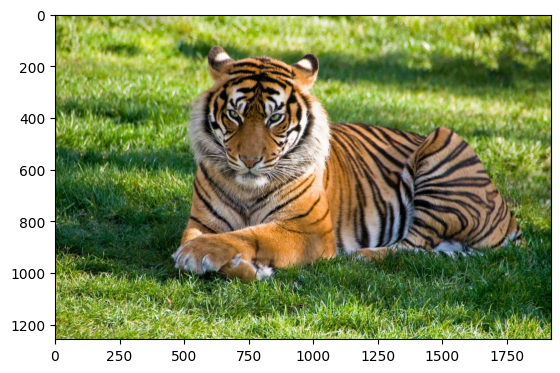

In [12]:
# model
weights = models.VGG16_Weights.DEFAULT
# weights=models.VGG16_Weights.IMAGENET1K_FEATURES
# weights=models.VGG16_Weights.IMAGENET1K_V1

vgg16 = models.vgg16(weights=weights)
vgg16.eval()

# preprocessing
preprocess = weights.transforms()

# obraz
img = Image.open("tygrys.jpg")
input_tensor = preprocess(img)
input_batch = input_tensor.unsqueeze(0)

# predykcja
with torch.no_grad():
    output = vgg16(input_batch)

# softmax
probabilities = torch.nn.functional.softmax(output[0], dim=0)

# wynik
categories = weights.meta["categories"]
top5_prob, top5_catid = torch.topk(probabilities, 5)

plt.imshow(img)

for i in range(5):
    print(categories[top5_catid[i]], round(top5_prob[i].item() * 100, 2), "%")

Trenowanie bez wag początkowych.

In [ ]:
vgg16 = models.vgg16(weights=None)

def train_model(model, train_loader, optimizer, epochs=5):
    model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        i = 0
        for images, labels in train_loader:
            i=i+1
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")
    
    return model

num_classes = 10
vgg16.classifier[6] = nn.Linear(vgg16.classifier[6].in_features, num_classes)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
optimizer = optim.Adam(vgg16.parameters(), lr=0.0001)

dataset_root = './data'
# Dataset zostanie pobrany jak go nie ma
train_dataset = datasets.CIFAR10(root=dataset_root, train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

vgg16 = train_model(vgg16, train_loader, optimizer, epochs=10)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("VGG params:", count_params(vgg16))



def predict_top5(model, image, classes):
    model.eval()
    image = image.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(image)
        probs = torch.softmax(outputs, dim=1)

    top5_prob, top5_idx = torch.topk(probs, 5)

    for i in range(5):
        print(classes[top5_idx[0][i]], top5_prob[0][i].item())


img = Image.open("tygrys.jpg")
plt.imshow(img)

img_tensor = transform(img)

classes = train_dataset.classes
predict_top5(vgg16, img_tensor, classes)

100%|██████████| 170M/170M [02:29<00:00, 1.14MB/s] 


Extracting ./data\cifar-10-python.tar.gz to ./data


KeyboardInterrupt: 

Propozycja eksperymentów:

AlexNet vs VGG16

Dropout 0.3 vs 0.5 vs brak

Różne optymalizatory - Adam vs SGD

In [ ]:
# zmiana dropout

vgg16.classifier[2] = nn.Dropout(p=0.3)
vgg16.classifier[5] = nn.Dropout(p=0.3)

vgg16.classifier[2] = nn.Identity()
vgg16.classifier[5] = nn.Identity()